## What is most deamanded skills for the top 3 most popuar data roles?

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import ast
import seaborn as sns

# loading data
dataset = load_dataset('Lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_USA = df[df['job_country']=="United States"]

In [3]:
df_skills = df_USA.explode('job_skills')
df_skills[['job_title','job_skills']].dropna()

,job_title,job_skills
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,aws
...,...,...
785692,Data Scientist- Hybrid Work Location,matlab
785692,Data Scientist- Hybrid Work Location,r
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [4]:
df_skill_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name='count').sort_values(by='count',ascending=False)
df_skill_count

,job_skills,job_title_short,count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [5]:
job_titles = df_skill_count['job_title_short'].unique().tolist()
job_titles = job_titles[:3]
job_titles

['Data Scientist', 'Data Analyst', 'Data Engineer']

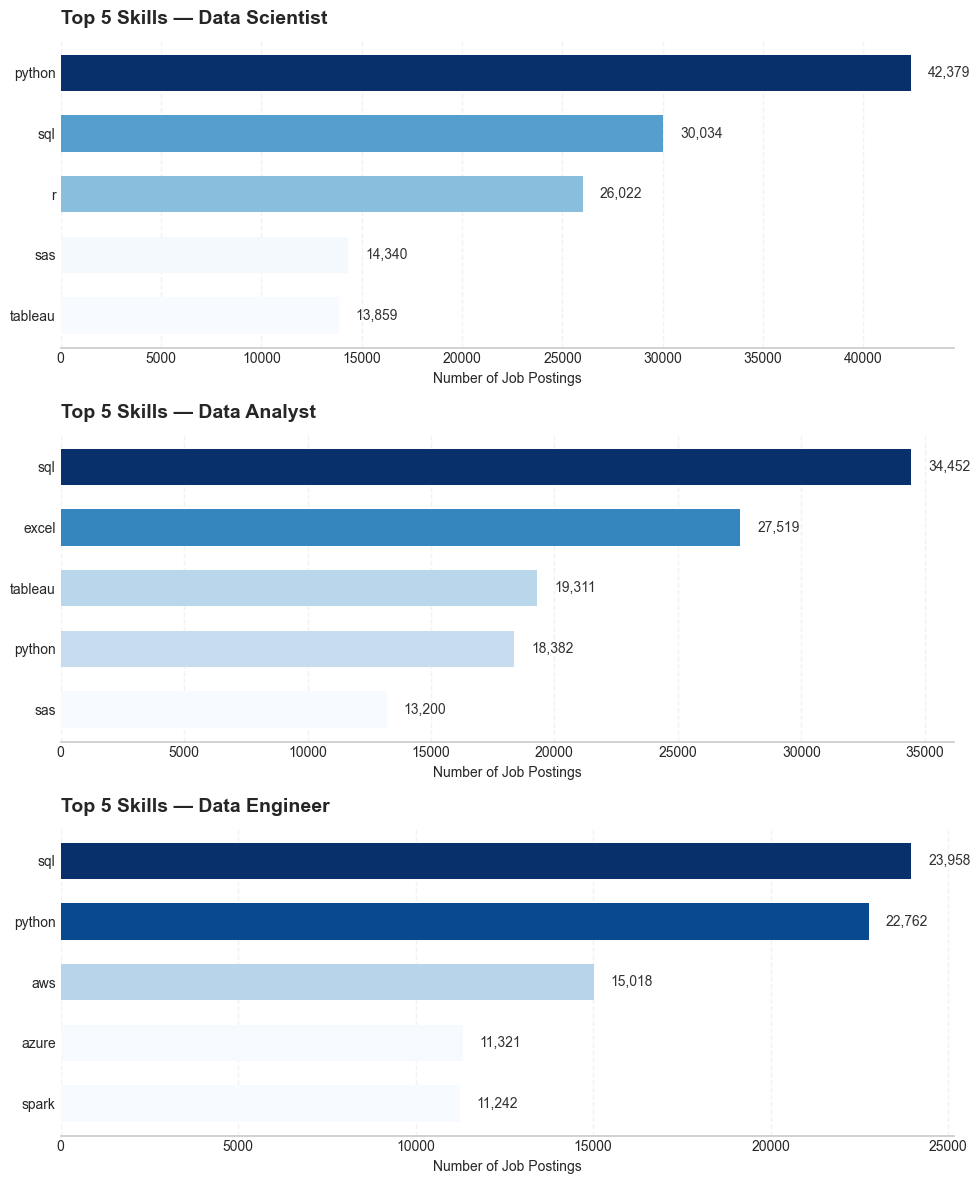

In [22]:
import matplotlib as mpl
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(nrows=len(job_titles),ncols=1,figsize=(10, 4 * len(job_titles)))

if len(job_titles) == 1:
    ax = [ax]


cmap = plt.cm.Blues

for i, job_title in enumerate(job_titles):

    df_plot = (df_skill_count[df_skill_count["job_title_short"] == job_title].sort_values("count",ascending=False).head(5))
    ax[i].invert_yaxis()
    
    norm = mpl.colors.Normalize(vmin=df_plot["count"].min(),vmax=df_plot["count"].max())

    
    colors = cmap(norm(df_plot["count"]+ 0.50))

    bars = ax[i].barh(df_plot["job_skills"],df_plot["count"],color=colors,edgecolor="none",height=0.6)

    ax[i].set_title(f"Top 5 Skills — {job_title}",fontsize=14,fontweight="bold",loc="left",pad=12)

    ax[i].set_xlabel("Number of Job Postings", fontsize=10)
    ax[i].set_ylabel("")

   
    for bar in bars:
        width = bar.get_width()

        ax[i].text(width + df_plot["count"].max() * 0.02,bar.get_y() + bar.get_height() / 2,f"{int(width):,}",
        va="center",fontsize=10,color="#333333")

    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["left"].set_visible(False)

    ax[i].grid(axis="x",linestyle="--",alpha=0.25)
    ax[i].grid(axis="y", visible=False)

    ax[i].tick_params(axis="both",labelsize=10,length=0)

plt.tight_layout()
plt.show()


In [8]:
df_job_count = df_USA['job_title_short'].value_counts().reset_index(name='job_total')

In [13]:
df_skill_prcn = pd.merge(df_skill_count,df_job_count,on='job_title_short',how='left')
df_skill_prcn['skill_percn'] = (df_skill_prcn['count'] / df_skill_prcn['job_total'])*100
df_skill_prcn

,job_skills,job_title_short,count,job_total,skill_percn
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


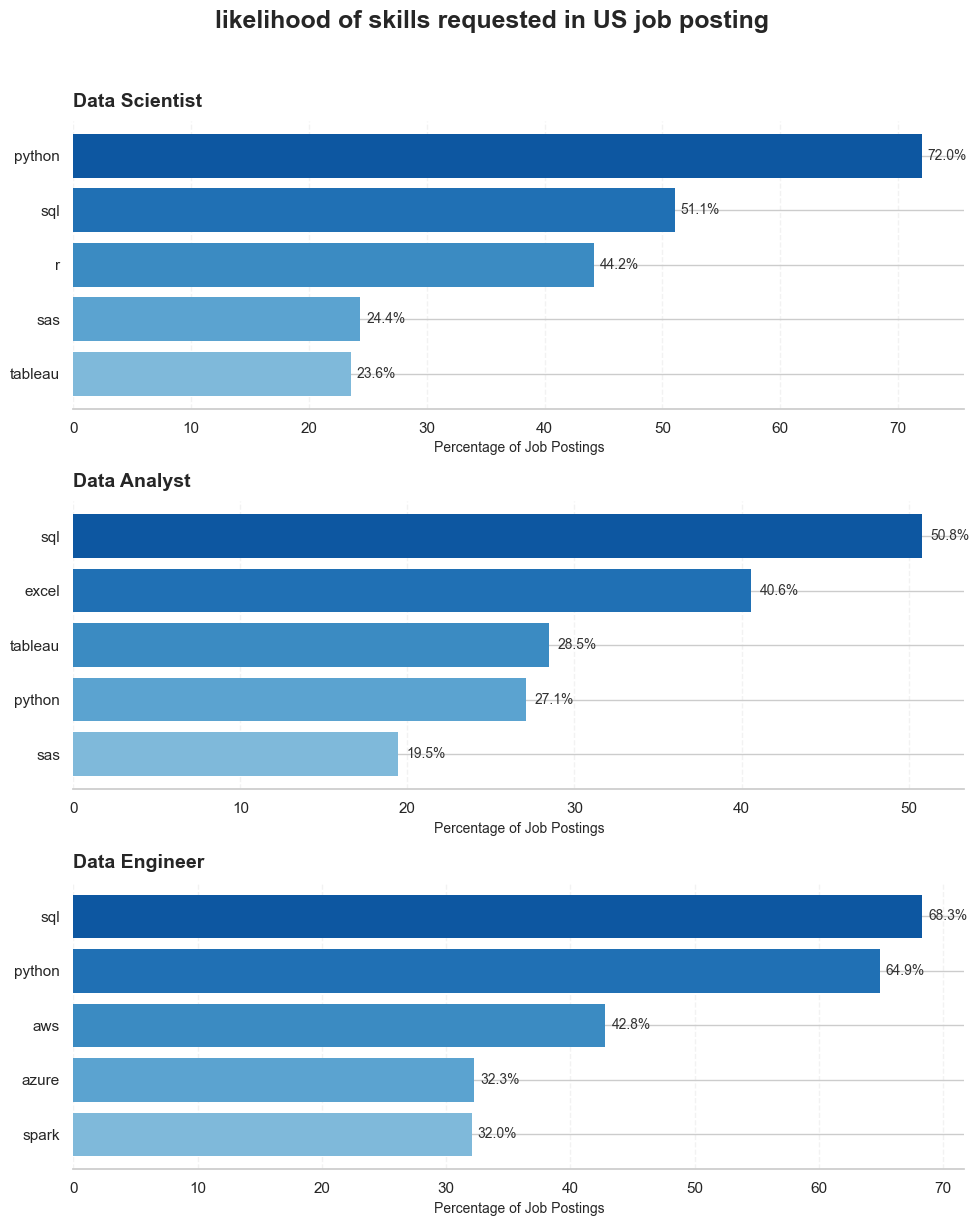

In [27]:
fig, axes = plt.subplots(
    nrows=len(job_titles),
    ncols=1,
    figsize=(10, 4 * len(job_titles))
)


if len(job_titles) == 1:
    axes = [axes]


colors = mpl.colormaps["Blues"]

for ax, job_title in zip(axes, job_titles):

    
    data = (
        df_skill_prcn[df_skill_prcn["job_title_short"] == job_title]
        .head(5)
        .sort_values("skill_percn")
    )

    
    bar_colors = colors(
        [0.45 + (i / len(data)) * 0.5 for i in range(len(data))]
    )

    
    bars = ax.barh(
        data["job_skills"],
        data["skill_percn"],
        color=bar_colors,
        edgecolor="none"
    )

    
    ax.set_title(
        job_title,
        fontsize=14,
        fontweight="bold",
        loc="left",
        pad=10
    )

    
    ax.set_xlabel("Percentage of Job Postings", fontsize=10)
    ax.set_ylabel("")

    
    for bar, value in zip(bars, data["skill_percn"]):
        ax.text(value + 0.5,bar.get_y() + bar.get_height() / 2,f"{value:.1f}%",va="center",fontsize=10,color="#333333")

    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


fig.suptitle(
    "likelihood of skills requested in US job posting",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()
